# Solve a colored bandaged cube

Select the **v2/.venv** Python kernel and run the cells below. The example is a scrambled Alcatraz; replace its input with your puzzle.

`specification` describes bandages in the **solved reference layout**. Use a named fixture or `c.Shape([...])` with your 27-cell bandage list.

Letters name the colors of the fixed **U, R, F, D, L, B centers**; translate your physical colors to those letters. Read each face in numbered order in this unfolded net, viewed from outside:

```text
          U1 U2 U3
          U4 U5 U6
          U7 U8 U9
L1 L2 L3  F1 F2 F3  R1 R2 R3  B1 B2 B3
L4 L5 L6  F4 F5 F6  R4 R5 R6  B4 B5 B6
L7 L8 L9  F7 F8 F9  R7 R8 R9  B7 B8 B9
          D1 D2 D3
          D4 D5 D6
          D7 D8 D9
```

Keep **B at the top of U**, **F at the top of D**, and **U at the top of each side face**. The 3D preview shows opposite **UFR** and **BLD** corner views, related by a half-turn about the line through the **FL and BR edge centers**. Center letters identify the faces; thick black lines outline bandages.

In [1]:
import bce_v2 as c

specification = c.fixture("Alcatraz")
facelets = (
    "UURUUDLLD"  # U
    "RRURRURRU"  # R
    "FFBFFBFFB"  # F
    "RRUDDUDDL"  # D
    "LLDLLDLLD"  # L
    "FBBFBBFBB"  # B
)
state = c.State.from_facelets(facelets, specification)

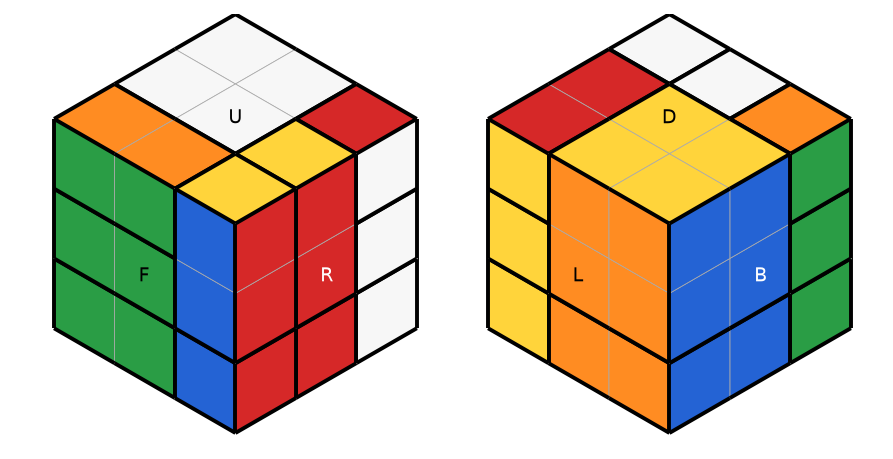

In [2]:
c.draw_cubes(state, colors=True, views=("UFR", "BLD"))

In [3]:
result = c.solve_colored(state, metric="HTM", max_states=100_000)
print("Status:", result.status)
if result.status == "solved":
    print("Shortest solution:", result.solution or "(already solved)")
    print("Move count:", result.distance)
    assert state.apply(result.solution).is_solved
elif result.status == "limit_reached":
    print("Search stopped at", result.stop_reason, "— raise or remove max_states and rerun.")

Status: solved
Shortest solution: R2 F'
Move count: 2


In [4]:
graph = c.explore_colored(
    c.State(specification), metric="QTM", max_states=1_000_000
)
print("Colored states:", len(graph))
print("Exact count:", graph.complete)

Colored states: 469476
Exact count: True


## Distances from solved

Use the complete enumeration above to count states at each shortest distance from solved. Distance 0 is the solved state. The metric is taken from `graph`.

In [5]:
from collections import Counter
from IPython.display import HTML, display

if not graph.complete:
    raise ValueError("Increase max_states and finish enumeration before computing the full distance table.")

solved = c.State(specification)
distances = graph.distances(solved)
counts = Counter(distances)
rows = "".join(
    f"<tr><td>{distance}</td><td>{count:,}</td></tr>"
    for distance, count in sorted(counts.items())
)
display(HTML(
    f"<table><thead><tr><th>Distance ({graph.metric})</th><th>Colored states</th></tr></thead>"
    f"<tbody>{rows}</tbody><tfoot><tr><th>Total</th><td>{len(graph):,}</td></tr></tfoot></table>"
))

Distance (QTM),Colored states
0,1
1,6
2,19
3,40
4,60
5,94
6,164
7,254
8,334
9,482


## Farthest states

Each example shows its stable hex ID, a shortest move sequence from solved, and both opposite corner views. IDs include the reference bandages and cubie colors in the fixed center frame. Change `show` to display more examples.


Maximum distance from solved: 40 QTM
States at maximum distance: 4
Showing 4 examples.
Hex ID: 051450c30ffe00101600060a04120e06121604100a0c0e08011403
From solved (40 QTM): U F' U' F U' R' U F R U F' U' R' F R F' R' F' U F F U' R' F R R F' U F' U U R U R R U' R R U U


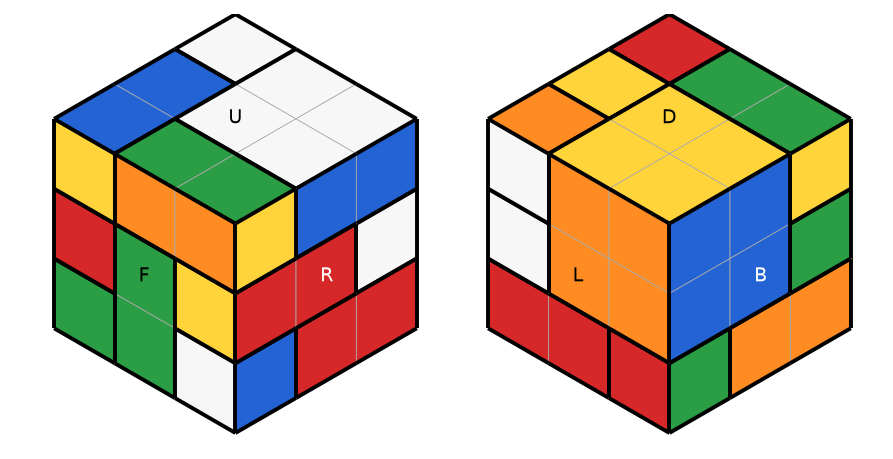

Hex ID: 051450c30ffe0011060117090d12031304061708110c0e0b021400
From solved (40 QTM): U F' U' F R' F' U F U' F R F' U' R' U F U F F U' F R F F R' F F U' R U U F' U' F F U F F U U


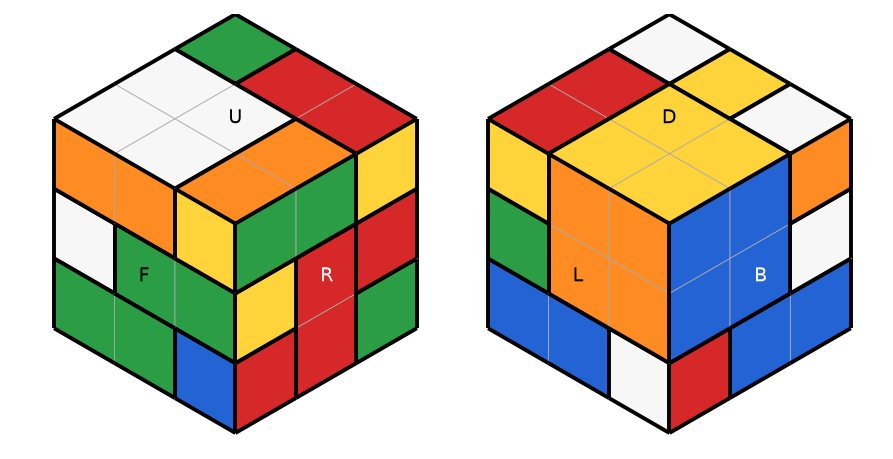

Hex ID: 051450c30ffe0017060011050d120b1704061308110c0e0b001402
From solved (40 QTM): U' R U R R F R F' R' F' U F F U' R R U' R R U U F' U' R' F R U' R U F' U' R U R' F U F F U U


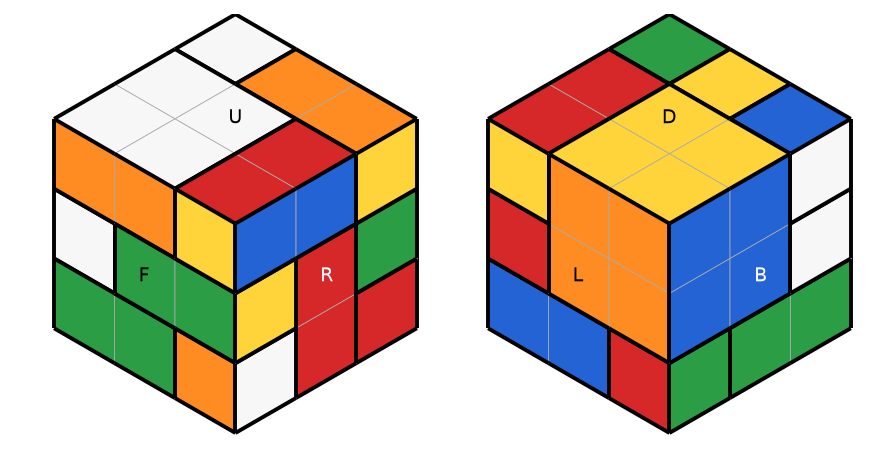

Hex ID: 051450c30ffe00161002060309120e06161204100a0c0e08031401
From solved (40 QTM): U' R U R' F R U' R' U R' F' R U F U' R' U' R R U R' F' R R F R R U F' U U R U R R U' R R U U


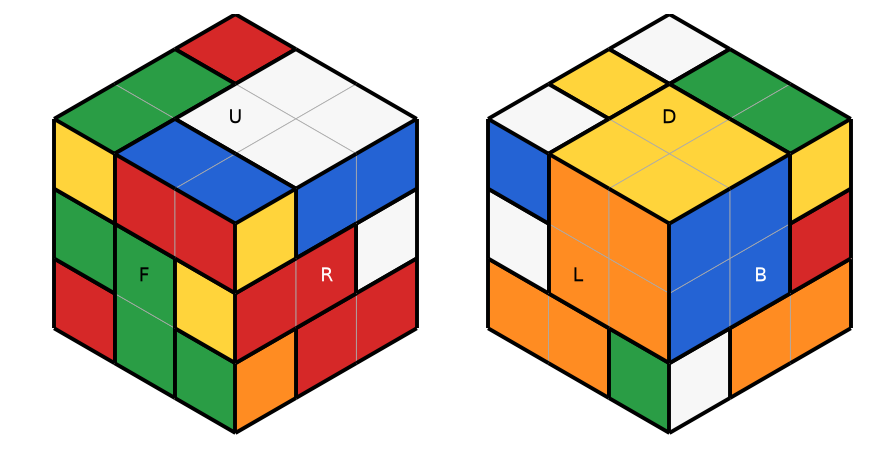

In [6]:
import matplotlib.pyplot as plt

max_distance = max(counts)
farthest_ids = [vertex for vertex, distance in enumerate(distances) if distance == max_distance]
show = 4
print(f"Maximum distance from solved: {max_distance} {graph.metric}")
print(f"States at maximum distance: {len(farthest_ids):,}")
print(f"Showing {min(show, len(farthest_ids))} examples.")
for vertex in farthest_ids[:show]:
    farthest = graph[vertex]
    moves = graph.shortest_path(solved, vertex)
    assert solved.apply(moves) == farthest
    print(f"Hex ID: {farthest.hex_id}")
    print(f"From solved ({max_distance} {graph.metric}): {moves}")
    figure = c.draw_cubes(farthest, colors=True, views=("UFR", "BLD"))
    display(figure)
    plt.close(figure)
